In [2]:
import pandas as pd 
import numpy as np

df = pd.read_csv("hotel_bookings.csv")
df.shape

(119390, 32)

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [5]:
df.isnull().sum().sort_values(ascending=False)

company                           112593
agent                              16340
country                              488
children                               4
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
hotel                                  0
previous_cancellations                 0
days_in_waiting_list                   0
customer_type                          0
adr                                    0
required_car_parking_spaces            0
total_of_special_requests              0
reservation_status                     0
previous_bookings_not_canceled         0
is_repeated_guest                      0
is_canceled                            0
distribution_channel                   0
market_segment                         0
meal                                   0
babies                                 0
adults                                 0
stays_in_week_ni

In [6]:
# Handling missing values
df['children'] = df['children'].fillna(0)
df = df.drop(['company'], axis = 1) # dropping company column, too many missing values
df['agent'] = df['agent'].fillna(0)
df['country'] = df['country'].fillna('Unknown')

In [7]:
df['hotel'].value_counts()

City Hotel      79330
Resort Hotel    40060
Name: hotel, dtype: int64

In [8]:
# Total nights and total guests features
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']

### Lead Time vs Cancellation

In [10]:
# Cancellation Rate 
cancel_rate = df['is_canceled'].mean()
print(cancel_rate)

0.37041628277075134


37% cancellation rate is very high and introduces significant uncertainty in demand forecasting, revenue planning and operational decisions like staffing and inventory allocation.

In [11]:
df.groupby('is_canceled')['lead_time'].mean()

is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64

Lead time insight:
- Non-canceled: ~80 days
- Canceled: ~145 days

Bookings made further in advance are nearly twice as likely to cancel, suggesting that early demand signals are less reliable and should be discounted in forecasting models. Early bookings carry higher uncertainty and should be adjusted in demand planning.

- Forecast should be weighted by lead time.
- Early bookings does NOT mean guaranteed demand.
- Overbooking should be higher for long lead segments.

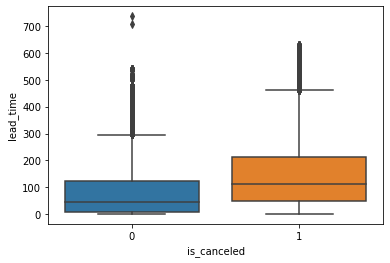

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x = 'is_canceled', y = 'lead_time', data = df)
plt.show()

Canceled bookings have higher lead time. Bookings made far in advance are significantly more likely to cancel. 

In [20]:
df['lead_time_bucket'] = pd.cut(df['lead_time'],
                               bins=[-1, 7, 30, 90, 180, 365],
                               labels=['0-7','8-30','31-90','91-180','180+'])

df.groupby('lead_time_bucket')['is_canceled'].mean()

lead_time_bucket
0-7       0.096323
8-30      0.278639
31-90     0.376984
91-180    0.447105
180+      0.554540
Name: is_canceled, dtype: float64

Cancellation risk increases non-linearly with lead time. 0-7 days lead time has very little cancellation rate while as the lead time increases there's a higher chance of having the booking canceled. Especially 90 days and above have about %44-55 cancellation rate. Lead time should be segmented into risk tiers rather than being treated as continous variables. 

Actions to consider to increase revenue:
- Different overbooking levels per bucket.
- Different cancellation policies. 

### Deposit Type vs Cancellation

In [21]:
df.groupby('deposit_type')['is_canceled'].mean()

deposit_type
No Deposit    0.283770
Non Refund    0.993624
Refundable    0.222222
Name: is_canceled, dtype: float64

In [23]:
df['deposit_type'].value_counts()

No Deposit    104641
Non Refund     14587
Refundable       162
Name: deposit_type, dtype: int64

### Customer Type

In [13]:
df.groupby('customer_type')['is_canceled'].mean().sort_values()

customer_type
Group              0.102253
Transient-Party    0.254299
Contract           0.309617
Transient          0.407463
Name: is_canceled, dtype: float64

Customer type is a strong predictor of booking reliability. Group bookings behave more like committed demand with stable revenue, while transient booking are more price-sensitive and show volatile demand. This distinction between customer types suggest segmentation-based forecasting should be used rather than treating all demand equally.

### Demand Pattern (Seasonality)

In [15]:
monthly_bookings = df['arrival_date_month'].value_counts()
monthly_bookings

August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: arrival_date_month, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

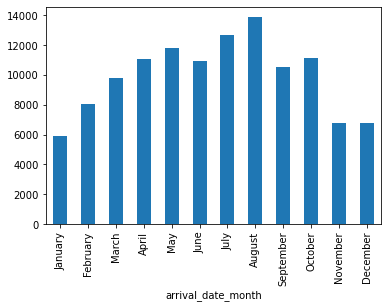

In [16]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories = month_order, ordered = True)

df.groupby('arrival_date_month').size().plot(kind = 'bar')
plt.show()

Demand shows strong seasonality, with peak volume in summer months and significant drop-offs in winter, which has direct implications for pricing strategy, promotional timing and staffing.

- High demand implies higher pricing power while low demand needs promotions. This supports dynamic pricing strategies to be used based on seasonality.

### Market Segment - Conversion Insight

In [17]:
df.groupby('market_segment')['is_canceled'].mean().sort_values()

market_segment
Complementary    0.130552
Direct           0.153419
Corporate        0.187347
Aviation         0.219409
Offline TA/TO    0.343160
Online TA        0.367211
Groups           0.610620
Undefined        1.000000
Name: is_canceled, dtype: float64

Distribution channel plays a key role in boooking relaibility and revenue predictability. 

**Online TA (Travel Agent):** Booking.com, Expedia, etc.
- Individual travelers booking online
- More flexible but higher cancellation rate.

**Offline TA/TO (Tour Operator):** Traditional travel agents or tour packages
- More structured but still somewhat flexible.

Online travel agencies tend to drive higher volume but lower relaibility due to flexible booking behavior.

Group bookings coming through distribution channels often have high cancellation rates because they represent tentative or bulk reservations. However, once those bookings are confirmed and classified as group customers, they becoma highly reliable. This highlights the importance of distinguishing between provisional demand and committed demand in forecasting.

In [13]:
df['distribution_channel'].value_counts()

TA/TO        97870
Direct       14645
Corporate     6677
GDS            193
Undefined        5
Name: distribution_channel, dtype: int64

### ADR - Average Daily Rate Insight

In [18]:
df.groupby('is_canceled')['adr'].mean()

is_canceled
0     99.987693
1    104.964333
Name: adr, dtype: float64

Canceled ADR is $5 more than non-canceled bookings. Higher priced bookings show slightly higher cancellation rates, suggesting price sensitivity or strategic rebooking behavior. Customers may shop around or rebook at better prices. 

Pricing strategy needs to account for elasticity as higher-value bookings may not always translate into realized revenue.

Overall, the analysis shows that demand is not uniform. Booking reliability varies significantly by lead time, customer type and distribution channel.

Early bookings and OTA-driven demand introduce higher uncertainty, while group and repeat customers provide more stable revenue streams.

This suggests that effective revenue management should incorporate risk-adjusted forecasting, segment-specific strategies and dynamic pricing based on both seasonality and booking behavior.